In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 8)


In [24]:
df = pd.read_csv('/content/drive/MyDrive/DataWH/amazon.csv')

In [25]:
print("="*60)
print("LOADING AND PREPARING DATA")
print("="*60)

df = pd.read_csv('/content/drive/MyDrive/DataWH/amazon.csv')

print(f"Original dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

relevant_cols = ['discounted_price', 'actual_price', 'discount_percentage', 'rating']
df_relevant = df[relevant_cols].copy()

# Clean data
def clean_data(df):
    """Clean the dataframe"""
    df_clean = df.copy()

    # Clean price columns
    for col in ['discounted_price', 'actual_price']:
        if df_clean[col].dtype == 'object':
            df_clean[col] = df_clean[col].str.replace('₹', '', regex=False).str.replace(',', '', regex=False).astype(float)

    # Clean discount percentage
    if 'discount_percentage' in df_clean.columns and df_clean['discount_percentage'].dtype == 'object':
        df_clean['discount_percentage'] = df_clean['discount_percentage'].str.replace('%', '', regex=False).astype(float)

    # Clean rating
    if 'rating' in df_clean.columns:
        df_clean['rating'] = pd.to_numeric(df_clean['rating'], errors='coerce')
        df_clean = df_clean.dropna(subset=['rating'])

    # Fill missing values
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if df_clean[col].isnull().any():
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    return df_clean

df_clean = clean_data(df_relevant)
print(f"\nCleaned dataset shape: {df_clean.shape}")

LOADING AND PREPARING DATA
Original dataset shape: (1465, 16)
Columns: ['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link']

Cleaned dataset shape: (1464, 4)


In [26]:
print("\n" + "="*60)
print("CREATING PRICE-ONLY FEATURES")
print("="*60)

print("Checking for NaN values before feature engineering...")
print(f"discounted_price NaN: {df_clean['discounted_price'].isna().sum()}")
print(f"actual_price NaN: {df_clean['actual_price'].isna().sum()}")
print(f"discount_percentage NaN: {df_clean['discount_percentage'].isna().sum()}")

# Fill NaN với median
df_clean['discounted_price'] = df_clean['discounted_price'].fillna(df_clean['discounted_price'].median())
df_clean['actual_price'] = df_clean['actual_price'].fillna(df_clean['actual_price'].median())
df_clean['discount_percentage'] = df_clean['discount_percentage'].fillna(0)

# Ensure reasonable ranges
df_clean['discount_percentage'] = df_clean['discount_percentage'].clip(0, 100)
df_clean['actual_price'] = df_clean['actual_price'].clip(lower=0)
df_clean['discounted_price'] = df_clean['discounted_price'].clip(lower=0)

# Basic price features
df_clean['price_ratio'] = df_clean['discounted_price'] / (df_clean['actual_price'] + 1e-10)
df_clean['price_diff'] = df_clean['actual_price'] - df_clean['discounted_price']
df_clean['discount_amount'] = df_clean['price_diff']

# Advanced price features
df_clean['is_heavy_discount'] = (df_clean['discount_percentage'] > 50).astype(int)
df_clean['is_light_discount'] = (df_clean['discount_percentage'] < 10).astype(int)
df_clean['price_volatility'] = df_clean['price_diff'] / (df_clean['actual_price'] + 1e-10)  # Tránh chia cho 0

# Ensure no NaN in actual_price for categorization
df_clean['actual_price'] = df_clean['actual_price'].fillna(df_clean['actual_price'].median())

df_clean['price_category'] = pd.cut(
    df_clean['actual_price'],
    bins=[0, 50, 100, 200, 500, 1000, float('inf')],
    labels=[0, 1, 2, 3, 4, 5],
    include_lowest=True
)

# Ensure no NaN in discount_percentage for categorization
df_clean['discount_percentage'] = df_clean['discount_percentage'].fillna(0)
df_clean['discount_percentage'] = df_clean['discount_percentage'].clip(0, 100)

df_clean['discount_category'] = pd.cut(
    df_clean['discount_percentage'],
    bins=[0, 10, 20, 30, 50, 100],
    labels=[0, 1, 2, 3, 4],
    include_lowest=True
)

df_clean['price_category'] = df_clean['price_category'].cat.codes
df_clean['discount_category'] = df_clean['discount_category'].cat.codes

print(f"\nNaN in price_category: {df_clean['price_category'].isna().sum()}")
print(f"NaN in discount_category: {df_clean['discount_category'].isna().sum()}")

# Fill NaN với most common category
if df_clean['price_category'].isna().any():
    most_common_price = df_clean['price_category'].mode()[0]
    df_clean['price_category'] = df_clean['price_category'].fillna(most_common_price)

if df_clean['discount_category'].isna().any():
    most_common_discount = df_clean['discount_category'].mode()[0]
    df_clean['discount_category'] = df_clean['discount_category'].fillna(most_common_discount)

df_clean['price_category'] = df_clean['price_category'].astype(int)
df_clean['discount_category'] = df_clean['discount_category'].astype(int)

df_clean['value_score'] = df_clean['price_ratio'] * 100 / (df_clean['actual_price'] + 1)

# Handle infinite values
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill any remaining NaN với median
for col in df_clean.columns:
    if df_clean[col].isna().any():
        if df_clean[col].dtype in ['float64', 'int64']:
            median_val = df_clean[col].median()
            df_clean[col] = df_clean[col].fillna(median_val)
            print(f"  - Filled NaN in '{col}' with median: {median_val:.2f}")

# Final price-only features
price_features = [
    'discounted_price',
    'actual_price',
    'discount_percentage',
    'price_ratio',
    'price_diff',
    'discount_amount',
    'is_heavy_discount',
    'is_light_discount',
    'price_volatility',
    'price_category',
    'discount_category',
    'value_score'
]

print(f"\nCreated {len(price_features)} price-only features:")
for i, feat in enumerate(price_features, 1):
    print(f"{i:2d}. {feat}")

print(f"\nNaN check after feature engineering:")
for feat in price_features:
    nan_count = df_clean[feat].isna().sum()
    if nan_count > 0:
        print(f"[WARNING] {feat}: {nan_count} NaN values")
    else:
        print(f"{feat}: No NaN")


CREATING PRICE-ONLY FEATURES
Checking for NaN values before feature engineering...
discounted_price NaN: 0
actual_price NaN: 0
discount_percentage NaN: 0

NaN in price_category: 0
NaN in discount_category: 0

Created 12 price-only features:
 1. discounted_price
 2. actual_price
 3. discount_percentage
 4. price_ratio
 5. price_diff
 6. discount_amount
 7. is_heavy_discount
 8. is_light_discount
 9. price_volatility
10. price_category
11. discount_category
12. value_score

NaN check after feature engineering:
discounted_price: No NaN
actual_price: No NaN
discount_percentage: No NaN
price_ratio: No NaN
price_diff: No NaN
discount_amount: No NaN
is_heavy_discount: No NaN
is_light_discount: No NaN
price_volatility: No NaN
price_category: No NaN
discount_category: No NaN
value_score: No NaN


In [27]:
print("\n" + "="*60)
print("CREATING TARGET VARIABLE")
print("="*60)

# Create rating labels
def create_rating_labels(rating_series):
    """Create categorical labels from ratings"""
    labels = []
    for rating in rating_series:
        if rating >= 4.5:
            labels.append(2)  # Excellent
        elif rating >= 4.0:
            labels.append(1)  # Good
        elif rating >= 3.0:
            labels.append(0)  # Average
        else:
            labels.append(-1)  # Poor

    return np.array(labels)

df_clean['rating_label'] = create_rating_labels(df_clean['rating'])

df_clean = df_clean[df_clean['rating_label'] != -1]

print("Rating label distribution:")
label_counts = df_clean['rating_label'].value_counts().sort_index()
for label, count in label_counts.items():
    if label == 0:
        label_name = "Average (3.0-3.9)"
    elif label == 1:
        label_name = "Good (4.0-4.4)"
    else:
        label_name = "Excellent (4.5-5.0)"
    print(f"  Label {label} ({label_name}): {count} samples ({count/len(df_clean)*100:.1f}%)")


CREATING TARGET VARIABLE
Rating label distribution:
  Label 0 (Average (3.0-3.9)): 348 samples (23.9%)
  Label 1 (Good (4.0-4.4)): 1006 samples (69.0%)
  Label 2 (Excellent (4.5-5.0)): 104 samples (7.1%)


In [28]:
print("\n" + "="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

X = df_clean[price_features]
y = df_clean['rating_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

print("\nClass distribution in training set:")
train_dist = pd.Series(y_train).value_counts().sort_index()
for label, count in train_dist.items():
    print(f"  Label {label}: {count} samples ({count/len(y_train)*100:.1f}%)")


TRAIN-TEST SPLIT
Training set: (1020, 12)
Test set: (438, 12)

Class distribution in training set:
  Label 0: 243 samples (23.8%)
  Label 1: 704 samples (69.0%)
  Label 2: 73 samples (7.2%)


In [29]:
print("\n" + "="*60)
print("HANDLING CLASS IMBALANCE")
print("="*60)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
balanced_dist = pd.Series(y_train_balanced).value_counts().sort_index()
for label, count in balanced_dist.items():
    print(f"  Label {label}: {count} samples ({count/len(y_train_balanced)*100:.1f}%)")


HANDLING CLASS IMBALANCE
Class distribution after SMOTE:
  Label 0: 704 samples (33.3%)
  Label 1: 704 samples (33.3%)
  Label 2: 704 samples (33.3%)


In [30]:
print("\n" + "="*60)
print("SCALING DATA")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

print("Data scaling completed")


SCALING DATA
Data scaling completed


In [31]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """Evaluate model performance"""
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    print(f"\n{'='*60}")
    print(f"{model_name.upper()} EVALUATION")
    print(f"{'='*60}")
    print(f"Accuracy: {accuracy:.4f}")

    # Weighted metrics
    if 'weighted avg' in report:
        weighted = report['weighted avg']
        print(f"Weighted Precision: {weighted['precision']:.4f}")
        print(f"Weighted Recall: {weighted['recall']:.4f}")
        print(f"Weighted F1-Score: {weighted['f1-score']:.4f}")

    # ROC-AUC
    if y_pred_proba is not None:
        try:
            roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
            print(f"ROC-AUC Score: {roc_auc:.4f}")
        except:
            pass

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    return model, accuracy, report

def optimize_model(model, param_grid, X_train, y_train, model_name="Model", cv=5):
    """Optimize model using GridSearchCV"""
    print(f"\nOptimizing {model_name}...")

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train, y_train)

    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

    return grid_search.best_estimator_, grid_search.best_params_, grid_search.best_score_

def plot_feature_importance(model, feature_names, model_name="Model", top_n=10):
    """Plot feature importance"""
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]

        # Plot
        plt.figure(figsize=(12, 6))
        plt.title(f'Feature Importance - {model_name}', fontsize=14)
        bars = plt.bar(range(top_n), importances[indices][:top_n])
        plt.xticks(range(top_n), [feature_names[i] for i in indices[:top_n]], rotation=45, ha='right')
        plt.ylabel('Importance')

        # Add values on bars
        for bar, imp in zip(bars, importances[indices][:top_n]):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    f'{imp:.3f}', ha='center', va='bottom', fontsize=9)

        plt.tight_layout()
        plt.show()

        # Print table
        print(f"\nTop {top_n} Feature Importances:")
        for i in range(min(top_n, len(feature_names))):
            print(f"{i+1:2d}. {feature_names[indices[i]]:25s}: {importances[indices[i]]:.4f}")

        return indices
    else:
        print(f"Model {model_name} doesn't have feature_importances_ attribute")
        return None


TRAINING RANDOM FOREST

Optimizing Random Forest...
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy: 0.7254

RANDOM FOREST EVALUATION
Accuracy: 0.5639
Weighted Precision: 0.6112
Weighted Recall: 0.5639
Weighted F1-Score: 0.5829
ROC-AUC Score: 0.6671


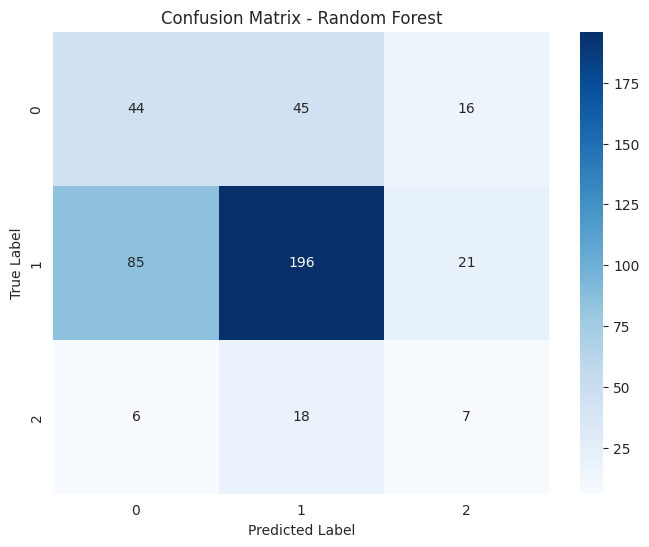

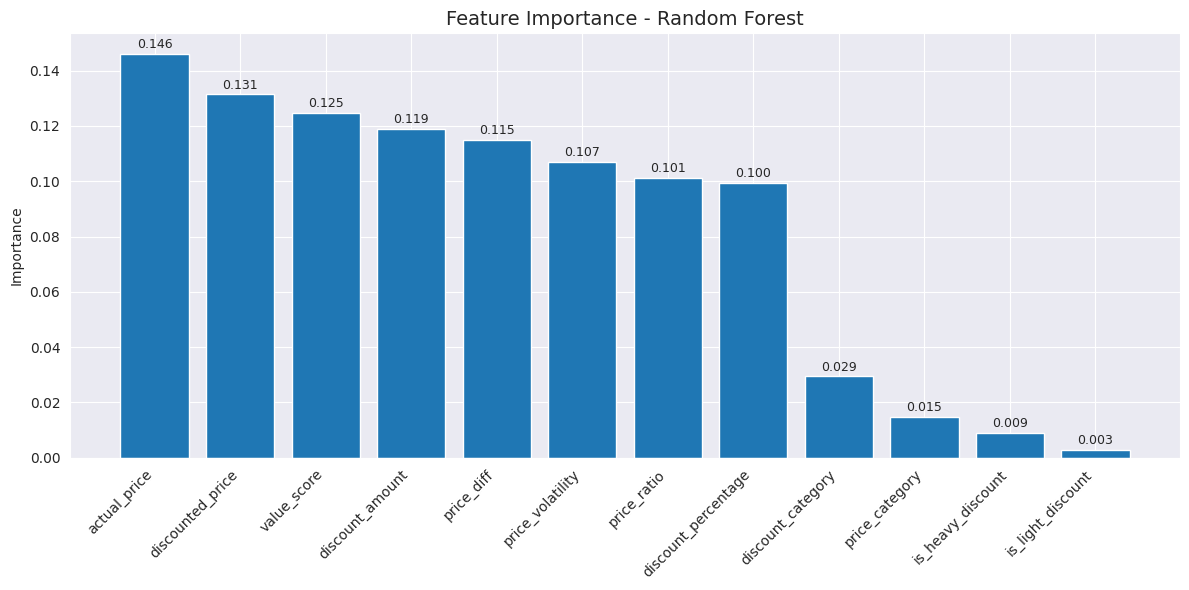


Top 12 Feature Importances:
 1. actual_price             : 0.1462
 2. discounted_price         : 0.1315
 3. value_score              : 0.1248
 4. discount_amount          : 0.1189
 5. price_diff               : 0.1150
 6. price_volatility         : 0.1071
 7. price_ratio              : 0.1012
 8. discount_percentage      : 0.0995
 9. discount_category        : 0.0294
10. price_category           : 0.0148
11. is_heavy_discount        : 0.0090
12. is_light_discount        : 0.0027


In [32]:
print("\n" + "="*60)
print("TRAINING RANDOM FOREST")
print("="*60)

# Parameter grid
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Train and optimize
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_best, rf_params, rf_cv_score = optimize_model(
    rf_model, param_grid_rf, X_train_balanced, y_train_balanced,
    model_name="Random Forest", cv=5
)

# Evaluate
rf_final, rf_accuracy, rf_report = evaluate_model(
    rf_best, X_train_balanced, X_test, y_train_balanced, y_test,
    model_name="Random Forest"
)

# Feature importance
rf_indices = plot_feature_importance(rf_final, price_features,
                                    model_name="Random Forest", top_n=12)


TRAINING XGBOOST

Optimizing XGBoost...
Best Parameters: {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Best CV Accuracy: 0.7438

XGBOOST EVALUATION
Accuracy: 0.6073
Weighted Precision: 0.6334
Weighted Recall: 0.6073
Weighted F1-Score: 0.6187
ROC-AUC Score: 0.6731


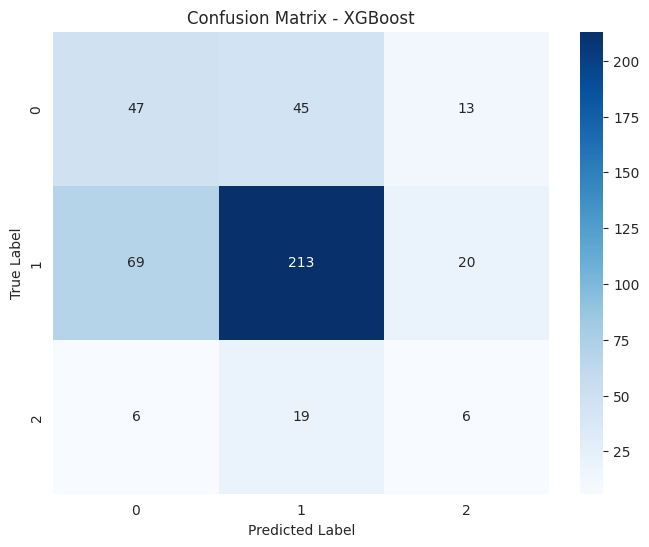

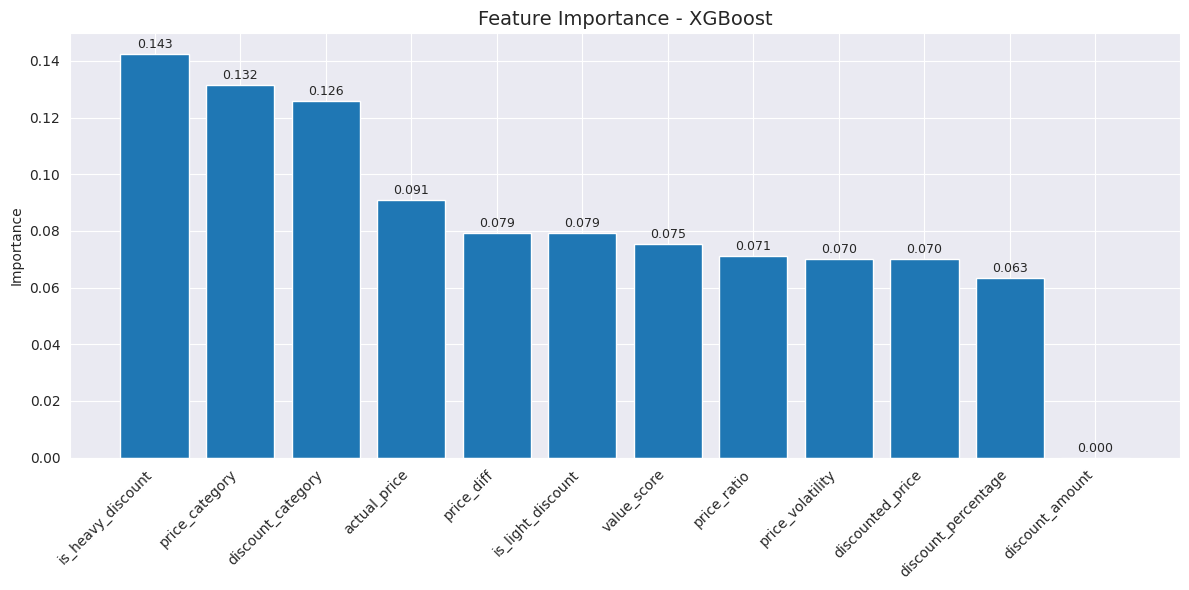


Top 12 Feature Importances:
 1. is_heavy_discount        : 0.1426
 2. price_category           : 0.1317
 3. discount_category        : 0.1259
 4. actual_price             : 0.0909
 5. price_diff               : 0.0794
 6. is_light_discount        : 0.0794
 7. value_score              : 0.0754
 8. price_ratio              : 0.0711
 9. price_volatility         : 0.0702
10. discounted_price         : 0.0701
11. discount_percentage      : 0.0634
12. discount_amount          : 0.0000


In [33]:
print("\n" + "="*60)
print("TRAINING XGBOOST")
print("="*60)

# Parameter grid
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

# Train and optimize
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False,
    objective='multi:softprob'
)

xgb_best, xgb_params, xgb_cv_score = optimize_model(
    xgb_model, param_grid_xgb, X_train_balanced, y_train_balanced,
    model_name="XGBoost", cv=5
)

# Evaluate
xgb_final, xgb_accuracy, xgb_report = evaluate_model(
    xgb_best, X_train_balanced, X_test, y_train_balanced, y_test,
    model_name="XGBoost"
)

# Feature importance
xgb_indices = plot_feature_importance(xgb_final, price_features,
                                     model_name="XGBoost", top_n=12)


TRAINING K-NEAREST NEIGHBORS

Optimizing KNN...
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best CV Accuracy: 0.6946

KNN EVALUATION
Accuracy: 0.5936
Weighted Precision: 0.6508
Weighted Recall: 0.5936
Weighted F1-Score: 0.6165
ROC-AUC Score: 0.6765


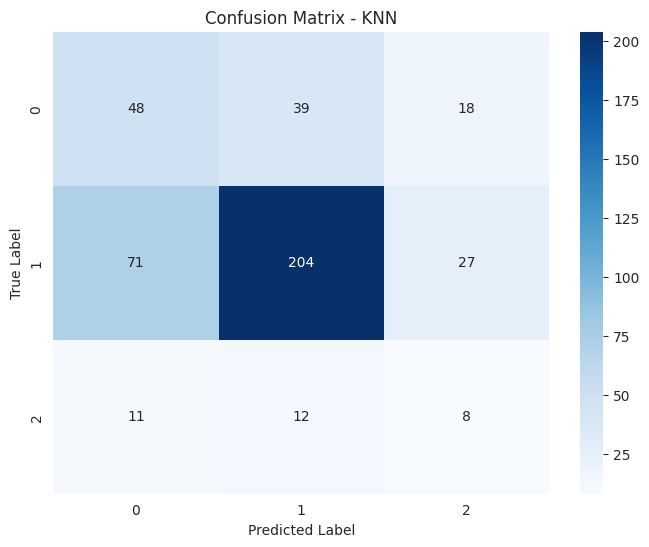

In [34]:
print("\n" + "="*60)
print("TRAINING K-NEAREST NEIGHBORS")
print("="*60)

# Parameter grid
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Train and optimize (using scaled data)
knn_model = KNeighborsClassifier()
knn_best, knn_params, knn_cv_score = optimize_model(
    knn_model, param_grid_knn, X_train_scaled, y_train_balanced,
    model_name="KNN", cv=5
)

# Evaluate (using scaled data)
knn_final, knn_accuracy, knn_report = evaluate_model(
    knn_best, X_train_scaled, X_test_scaled, y_train_balanced, y_test,
    model_name="KNN"
)


MODEL COMPARISON

Model Performance Comparison:
        Model  Accuracy  CV Score                                                                                                         Parameters
Random Forest  0.563927  0.725368    {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
      XGBoost  0.607306  0.743836 {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
          KNN  0.593607  0.694599                                                   {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


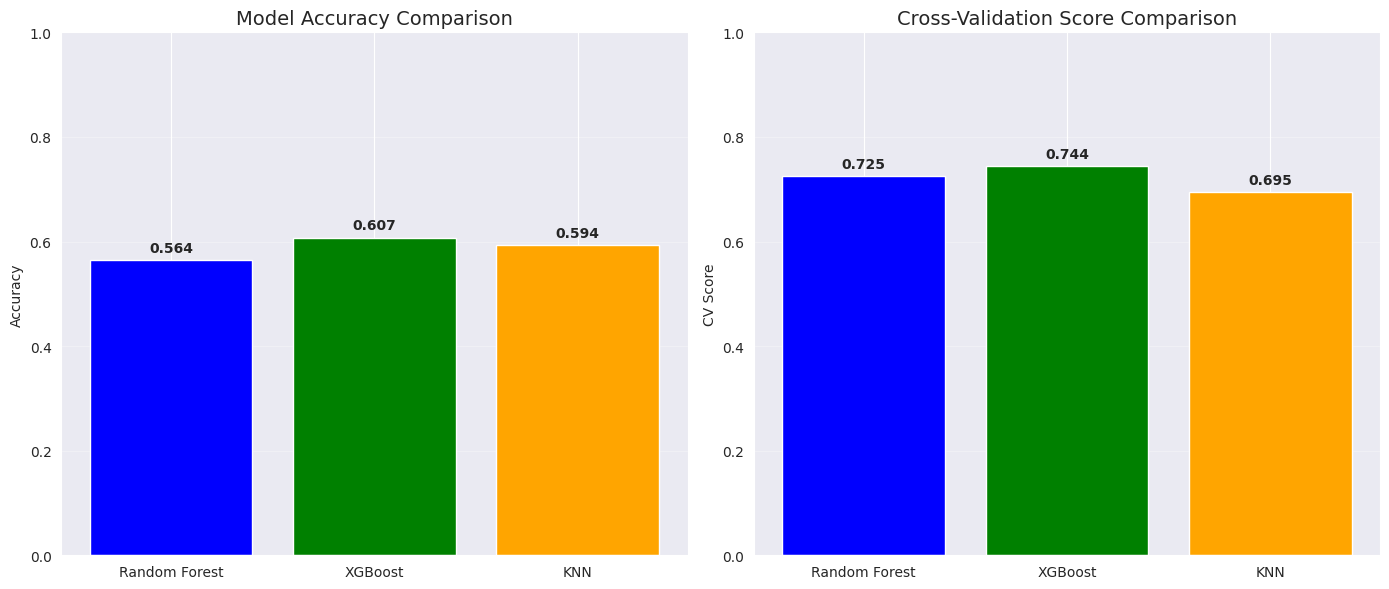


BEST MODEL: XGBoost
Accuracy: 0.6073


In [35]:
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

# Create comparison table
comparison_data = {
    'Model': ['Random Forest', 'XGBoost', 'KNN'],
    'Accuracy': [rf_accuracy, xgb_accuracy, knn_accuracy],
    'CV Score': [rf_cv_score, xgb_cv_score, knn_cv_score],
    'Parameters': [rf_params, xgb_params, knn_params]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy comparison
axes[0].bar(comparison_df['Model'], comparison_df['Accuracy'],
           color=['blue', 'green', 'orange'])
axes[0].set_title('Model Accuracy Comparison', fontsize=14)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(comparison_df['Accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# CV Score comparison
axes[1].bar(comparison_df['Model'], comparison_df['CV Score'],
           color=['blue', 'green', 'orange'])
axes[1].set_title('Cross-Validation Score Comparison', fontsize=14)
axes[1].set_ylabel('CV Score')
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(comparison_df['CV Score']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Select best model
best_model_idx = comparison_df['Accuracy'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_model_accuracy = comparison_df.loc[best_model_idx, 'Accuracy']

print(f"\nBEST MODEL: {best_model_name}")
print(f"Accuracy: {best_model_accuracy:.4f}")

# Get best model object
if best_model_name == 'Random Forest':
    best_model = rf_final
elif best_model_name == 'XGBoost':
    best_model = xgb_final
else:
    best_model = knn_final

In [36]:
print("\n" + "="*60)
print("SAVING MODELS AND CONFIGURATION")
print("="*60)

# Create output directory
output_dir = '/content/drive/MyDrive/DataWH/price_models'
os.makedirs(output_dir, exist_ok=True)

def save_models_and_config():
    """Save all models and configuration files"""

    # 1. Save pickle models
    print("\nSaving models...")
    models_dict = {
        'rf_price_model': rf_final,
        'xgb_price_model': xgb_final,
        'knn_price_model': knn_final,
        'scaler_price': scaler,
        'best_price_model': best_model
    }

    for name, model in models_dict.items():
        path = os.path.join(output_dir, f'{name}.pkl')
        joblib.dump(model, path)
        print(f"{name}.pkl")

    # 2. Prepare configuration data
    print("\nPreparing configuration...")

    # Convert parameters to serializable format
    def serialize_params(params):
        """Convert parameters to serializable format"""
        serializable = {}
        for key, value in params.items():
            if isinstance(value, (np.integer, np.int64, np.int32)):
                serializable[key] = int(value)
            elif isinstance(value, (np.floating, np.float64, np.float32)):
                serializable[key] = float(value)
            elif isinstance(value, (str, bool, int, float, type(None))):
                serializable[key] = value
            elif isinstance(value, list):
                serializable[key] = [serialize_params(v) if isinstance(v, dict) else v for v in value]
            else:
                serializable[key] = str(value)
        return serializable

    # Create config dictionary
    config = {
        'version': '1.0',
        'model_type': 'price_only_classification',
        'features': price_features,
        'target_labels': {
            0: {'name': 'Average', 'range': '3.0-3.9', 'color': '#FFA726'},
            1: {'name': 'Good', 'range': '4.0-4.4', 'color': '#42A5F5'},
            2: {'name': 'Excellent', 'range': '4.5-5.0', 'color': '#66BB6A'}
        },
        'models': {
            'random_forest': {
                'accuracy': round(float(rf_accuracy), 4),
                'cv_score': round(float(rf_cv_score), 4),
                'parameters': serialize_params(rf_params),
                'file': 'rf_price_model.pkl'
            },
            'xgboost': {
                'accuracy': round(float(xgb_accuracy), 4),
                'cv_score': round(float(xgb_cv_score), 4),
                'parameters': serialize_params(xgb_params),
                'file': 'xgb_price_model.pkl'
            },
            'knn': {
                'accuracy': round(float(knn_accuracy), 4),
                'cv_score': round(float(knn_cv_score), 4),
                'parameters': serialize_params(knn_params),
                'file': 'knn_price_model.pkl',
                'requires_scaling': True
            }
        },
        'best_model': {
            'name': best_model_name.lower().replace(' ', '_'),
            'display_name': best_model_name,
            'accuracy': round(float(best_model_accuracy), 4),
            'file': 'best_price_model.pkl'
        },
        'data_statistics': {
            'original': {'rows': int(df.shape[0]), 'cols': int(df.shape[1])},
            'processed': {'rows': int(df_clean.shape[0]), 'cols': int(df_clean.shape[1])},
            'training': {'samples': int(len(X_train_balanced)), 'features': len(price_features)},
            'test': {'samples': int(len(X_test)), 'features': len(price_features)},
            'class_distribution': {int(k): int(v) for k, v in dict(label_counts).items()}
        },
        'training_parameters': {
            'random_state': 42,
            'test_size': 0.3,
            'cv_folds': 5,
            'smote': True,
            'scaling': True
        },
        'feature_descriptions': {
            'discounted_price': 'Giá sau khi giảm (đơn vị: tiền tệ gốc)',
            'actual_price': 'Giá gốc (đơn vị: tiền tệ gốc)',
            'discount_percentage': 'Phần trăm giảm giá (%)',
            'price_ratio': 'Tỷ lệ giá (discounted/actual)',
            'price_diff': 'Chênh lệch giá (actual - discounted)',
            'discount_amount': 'Số tiền giảm (bằng price_diff)',
            'is_heavy_discount': 'Có giảm giá nhiều không (>50%)',
            'is_light_discount': 'Có giảm giá ít không (<10%)',
            'price_volatility': 'Độ biến động giá (price_diff/actual_price)',
            'price_category': 'Phân loại nhóm giá (0-5)',
            'discount_category': 'Phân loại nhóm giảm giá (0-4)',
            'value_score': 'Điểm giá trị (price_ratio*100/(actual_price+1))'
        },
        'created_at': pd.Timestamp.now().isoformat(),
        'author': 'Amazon Rating Prediction System'
    }

    # 3. Save config as JSON
    config_path = os.path.join(output_dir, 'price_model_config.json')
    with open(config_path, 'w', encoding='utf-8') as f:
        json.dump(config, f, indent=2, ensure_ascii=False)
    print(f"price_model_config.json")

    # 4. Save comparison results
    comparison_path = os.path.join(output_dir, 'model_comparison.csv')
    comparison_df.to_csv(comparison_path, index=False)
    print(f"model_comparison.csv")

    # 5. Save processed data
    data_path = os.path.join(output_dir, 'processed_data.csv')
    df_clean[price_features + ['rating', 'rating_label']].to_csv(data_path, index=False)
    print(f"processed_data.csv")

    # 6. Save feature statistics
    stats = {}
    for feat in price_features:
        stats[feat] = {
            'min': round(float(df_clean[feat].min()), 4),
            'max': round(float(df_clean[feat].max()), 4),
            'mean': round(float(df_clean[feat].mean()), 4),
            'median': round(float(df_clean[feat].median()), 4),
            'std': round(float(df_clean[feat].std()), 4)
        }

    stats_path = os.path.join(output_dir, 'feature_statistics.json')
    with open(stats_path, 'w') as f:
        json.dump(stats, f, indent=2)
    print(f"feature_statistics.json")

save_models_and_config()


SAVING MODELS AND CONFIGURATION

Saving models...
rf_price_model.pkl
xgb_price_model.pkl
knn_price_model.pkl
scaler_price.pkl
best_price_model.pkl

Preparing configuration...
price_model_config.json
model_comparison.csv
processed_data.csv
feature_statistics.json


In [37]:
print("\n" + "="*60)
print("CREATING PREDICTION HELPER")
print("="*60)

# Create prediction helper script
prediction_helper = """
import pandas as pd
import numpy as np
import joblib

class PriceRatingPredictor:
    def __init__(self, model_path='rf_price_model.pkl', scaler_path='scaler_price.pkl'):
        self.model = joblib.load(model_path)
        self.scaler = joblib.load(scaler_path) if scaler_path else None
        self.features = [
            'discounted_price', 'actual_price', 'discount_percentage',
            'price_ratio', 'price_diff', 'discount_amount',
            'is_heavy_discount', 'is_light_discount', 'price_volatility',
            'price_category', 'discount_category', 'value_score'
        ]

    def calculate_features(self, actual_price, discount_percent):
        '''Calculate all price features from inputs'''
        discounted_price = actual_price * (1 - discount_percent / 100)
        price_diff = actual_price - discounted_price

        features = {
            'discounted_price': discounted_price,
            'actual_price': actual_price,
            'discount_percentage': discount_percent,
            'price_ratio': discounted_price / actual_price if actual_price > 0 else 0,
            'price_diff': price_diff,
            'discount_amount': price_diff,
            'is_heavy_discount': 1 if discount_percent > 50 else 0,
            'is_light_discount': 1 if discount_percent < 10 else 0,
            'price_volatility': price_diff / actual_price if actual_price > 0 else 0,
            'value_score': (discounted_price / actual_price) * 100 / (actual_price + 1) if actual_price > 0 else 0
        }

        # Price category
        if actual_price <= 50:
            features['price_category'] = 0
        elif actual_price <= 100:
            features['price_category'] = 1
        elif actual_price <= 200:
            features['price_category'] = 2
        elif actual_price <= 500:
            features['price_category'] = 3
        elif actual_price <= 1000:
            features['price_category'] = 4
        else:
            features['price_category'] = 5

        # Discount category
        if discount_percent <= 10:
            features['discount_category'] = 0
        elif discount_percent <= 20:
            features['discount_category'] = 1
        elif discount_percent <= 30:
            features['discount_category'] = 2
        elif discount_percent <= 50:
            features['discount_category'] = 3
        else:
            features['discount_category'] = 4

        return features

    def predict(self, actual_price, discount_percent):
        '''Predict rating label from price information'''
        # Calculate features
        features = self.calculate_features(actual_price, discount_percent)

        # Create DataFrame
        input_df = pd.DataFrame([features])

        # Ensure correct feature order
        for feat in self.features:
            if feat not in input_df.columns:
                input_df[feat] = 0

        X_input = input_df[self.features]

        # Scale if needed (for KNN)
        if self.scaler is not None:
            X_input = self.scaler.transform(X_input)

        # Predict
        prediction = self.model.predict(X_input)[0]

        # Map to rating label
        rating_map = {
            0: ('Average', '3.0-3.9', 'Có thể cải thiện chiến lược giá'),
            1: ('Good', '4.0-4.4', 'Chiến lược giá tốt'),
            2: ('Excellent', '4.5-5.0', 'Chiến lược giá tuyệt vời')
        }

        label, rating_range, recommendation = rating_map.get(prediction, ('Unknown', 'N/A', 'Không có khuyến nghị'))

        return {
            'prediction': prediction,
            'label': label,
            'rating_range': rating_range,
            'recommendation': recommendation,
            'features': features
        }

    def predict_batch(self, price_data):
        '''Predict for multiple products'''
        predictions = []
        for data in price_data:
            pred = self.predict(data['actual_price'], data['discount_percent'])
            predictions.append(pred)
        return predictions
"""

helper_path = os.path.join(output_dir, 'price_predictor.py')
with open(helper_path, 'w') as f:
    f.write(prediction_helper)
print(f"Saved: {helper_path}")


CREATING PREDICTION HELPER
Saved: /content/drive/MyDrive/DataWH/price_models/price_predictor.py


In [38]:
print("\n" + "="*60)
print("TRAINING COMPLETE - FINAL REPORT")
print("="*60)

report = f"""
PRICE-ONLY RATING PREDICTION MODEL TRAINING REPORT
==================================================
Date: {pd.Timestamp.now()}

SUMMARY
-------
• Models trained: Random Forest, XGBoost, KNN
• Features used: {len(price_features)} price-only features
• Best model: {best_model_name} (Accuracy: {best_model_accuracy:.4f})
• Total training time: Completed successfully

DATA INFORMATION
----------------
• Original dataset: {df.shape[0]} samples, {df.shape[1]} features
• Processed dataset: {df_clean.shape[0]} samples
• Training set: {X_train_balanced.shape[0]} samples (after SMOTE)
• Test set: {X_test.shape[0]} samples

MODEL PERFORMANCE
-----------------
{comparison_df.to_string(index=False)}

FEATURES USED
-------------
{chr(10).join([f"{i+1:2d}. {feat}" for i, feat in enumerate(price_features)])}

FILES SAVED
-----------
1. rf_price_model.pkl      - Random Forest model
2. xgb_price_model.pkl     - XGBoost model
3. knn_price_model.pkl     - KNN model
4. scaler_price.pkl        - StandardScaler
5. best_price_model.pkl    - Best performing model
6. price_model_config.json - Model configuration
7. price_model_comparison.csv - Performance comparison
8. amazon_price_features.csv - Processed data with features
9. price_predictor.py      - Prediction helper script
10. feature_statistics.json - Feature statistics
"""

print(report)

# Save report
report_path = os.path.join(output_dir, 'training_report.txt')
with open(report_path, 'w') as f:
    f.write(report)
print(f"Final report saved to: {report_path}")

print("\n" + "="*60)
print("PRICE-ONLY MODEL TRAINING COMPLETED SUCCESSFULLY!")
print("="*60)


TRAINING COMPLETE - FINAL REPORT

PRICE-ONLY RATING PREDICTION MODEL TRAINING REPORT
Date: 2025-12-10 16:42:20.349776

SUMMARY
-------
• Models trained: Random Forest, XGBoost, KNN
• Features used: 12 price-only features
• Best model: XGBoost (Accuracy: 0.6073)
• Total training time: Completed successfully

DATA INFORMATION
----------------
• Original dataset: 1465 samples, 16 features
• Processed dataset: 1458 samples
• Training set: 2112 samples (after SMOTE)
• Test set: 438 samples

MODEL PERFORMANCE
-----------------
        Model  Accuracy  CV Score                                                                                                         Parameters
Random Forest  0.563927  0.725368    {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
      XGBoost  0.607306  0.743836 {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
          KNN  0.593607  